<a href="https://colab.research.google.com/github/gabrielcord/recpad20252/blob/main/IMDB_HuggingFace.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMDB com Hugging Face

**Aluno:** Gabriel Cordeiro

**Disciplina:** Redes Neurais Artificiais

**Semestre:** 2026/1

## Enunciado

Use a classe pipeline da biblioteca transformers do HuggingFace (Behind the pipeline - Hugging Face NLP Course) para analisar o sentimento da base IMBD https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz.

## Solução

### Preparação do dataset

#### Download da base

In [35]:
!curl -L https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz | tar -xz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 80.2M  100 80.2M    0     0  8263k      0  0:00:09  0:00:09 --:--:-- 6141k


#### Carregamento dos dados

In [36]:
import os
from datasets import Dataset, DatasetDict

base_path = "aclImdb/test"
ds = {"text": [], "label": []}

for label_name in ["pos", "neg"]:
  label_val = 1 if label_name == "pos" else 0
  folder_path = os.path.join(base_path, label_name)

  for filename in os.listdir(folder_path):
    if filename.endswith(".txt"):
      with open(os.path.join(folder_path, filename), "r", encoding="utf-8") as f:
        ds["text"].append(f.read())
        ds["label"].append(label_val)

print(f"Campos disponíveis: {list(ds.keys())}")
print(f"Quantidade de textos: {len(ds['text'])}")
print(f"Quantidade de rótulos: {len(ds['label'])}")

Campos disponíveis: ['text', 'label']
Quantidade de textos: 25000
Quantidade de rótulos: 25000


### Utilização do modelo pré-treinado

In [37]:
import torch
from transformers import pipeline

device = 0 if torch.cuda.is_available() else -1

pipe = pipeline("text-classification", model="lvwerra/distilbert-imdb", device=device)

# Evita erro de renderização no GitHub
from IPython.display import clear_output
clear_output(wait=True)

print(pipe)

TextClassificationPipeline: {'model': 'DistilBertForSequenceClassification', 'dtype': 'float32', 'device': 'cuda', 'input_modalities': 'text'}


#### Predição

In [38]:
predictions = pipe(ds["text"], batch_size=32, truncation=True)

#### Avaliação

Acurácia: 92.80%


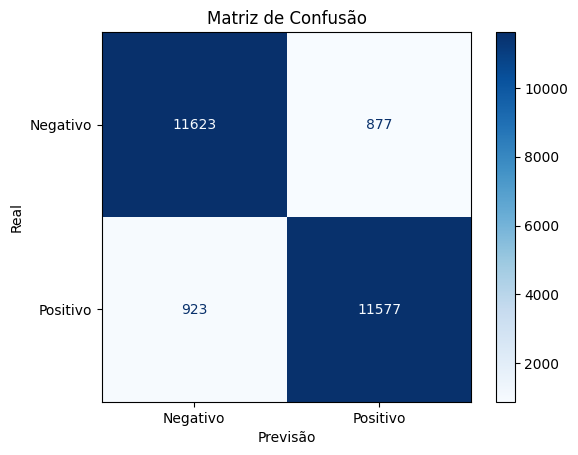

In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = [1 if p['label'] == 'POSITIVE' else 0 for p in predictions]
y_true = ds["label"]

acc_score = accuracy_score(y_true, y_pred)
print(f"Acurácia: {acc_score * 100:.2f}%")

cm = confusion_matrix(y_true, y_pred)
cm_disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negativo", "Positivo"])
cm_disp.plot(cmap=plt.cm.Blues)

plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Matriz de Confusão')

plt.show()

#### Exemplos de acertos e de erros

In [40]:
import pandas as pd

df = pd.DataFrame({
  'text': ds["text"],
  'y_true': y_true,
  'y_pred': y_pred,
  'score': [p['score'] for p in predictions]
})

n = 3

cases = {
  "Verdadeiro Positivo (TP)": (df['y_true'] == 1) & (df['y_pred'] == 1),
  "Verdadeiro Negativo (TN)": (df['y_true'] == 0) & (df['y_pred'] == 0),
  "Falso Positivo (FP)":      (df['y_true'] == 0) & (df['y_pred'] == 1),
  "Falso Negativo (FN)":      (df['y_true'] == 1) & (df['y_pred'] == 0)
}

for name, cond in cases.items():
  examples = df[cond].head(n)

  print(f"\n{'='*10} {name} ({len(examples)} exibidos) {'='*10}")

  if examples.empty:
    print("Nenhum exemplo encontrado.")
    continue

  for i, (_, row) in enumerate(examples.iterrows()):
    print(f"\nExemplo {i+1} (Confiança: {row['score']:.4f}):")
    print(f"Texto: {row['text'][:200]}...")
    print("-" * 30)


========== Verdadeiro Positivo (TP) (3 exibidos) ==========

Exemplo 1 (Confiança: 0.9558):
Texto: Initially I was put off renting this movie due to the jacket art for the DVD. In fact, this held true with friends of mine who didn't rent it due to the art and the mental image(s) it conjured of bein...
------------------------------

Exemplo 2 (Confiança: 0.5868):
Texto: I was surprised that I liked this movie. But it reminded me of a 2004 version of the first Friday the 13th. There were a number of cheesy elements, yet at the same time there were many cool ones. The ...
------------------------------

Exemplo 3 (Confiança: 0.6717):
Texto: This is one of Barbara Stanwyck's earlier films and it sure does have an unconventional theme. She's making money by dancing with men at a dance hall. She really doesn't like the work, but it's a livi...
------------------------------

========== Verdadeiro Negativo (TN) (3 exibidos) ==========

Exemplo 1 (Confiança: 0.9860):
Texto: Can I just start 